In [ ]:
# Make Figures 3 and 4 for benchmarking paper
# Compare benchmark-FATES difference

In [1]:
import numpy as np
from scipy import stats
#
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#
import shapefile
from shapely.geometry import shape
import shapely.vectorized
## this next library contains some helper functions for reshaping FATES variables into easier to work with dimensions
import ctsm_py
import ctsm_py.fates_xarray_funcs as fa       
#
import textwrap
from cmcrameri import cm
import cartopy
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader
#
import shapefile
import shapely
from shapely.geometry import shape

ERROR 1: PROJ: proj_create_from_database: Open of /global/homes/j/jkowalcz/.conda/envs/myenv/share/proj failed


In [2]:
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['figure.autolayout'] = False
plt.rcParams['font.size'] = 16
##plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 300

In [3]:
min_lat_plotting = -22.
max_lat_plotting = 12.
min_lon_plotting = 360.-82.
max_lon_plotting = 360.-42.

geog_range_plotting = [min_lon_plotting, max_lon_plotting, min_lat_plotting, max_lat_plotting]


In [4]:
# Shapefile for Amazon ecoregion
Amazon_shapefile='/global/homes/j/jkowalcz/shapefileamazonecoregionwwf/amazon_ecolola.shp'

In [5]:
# read in FATES output
fates_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/SummaryFiles/'
fates_tag='hydro_comp_bmort_kmax_tune_sapflow_kmax3_5xHR_fixSLA_vcmax40.55_fixHR_branch'
fates_file=fates_tag+'.elm.h0.cat.nc'
fates = xr.open_dataset(fates_path+fates_file)

In [6]:
def make_shapefile_mask(shapefile_path,dataset):
    r = shapefile.Reader(shapefile_path)
    polygon = shape(r.shapes()[0])

    # Standardize longitudes to the -180 to 180 range 
    lon_standardized = ((dataset.lon.values + 180) % 360) - 180

    #Create a 2D grid of your coordinates automatically
    lon_2d, lat_2d = np.meshgrid(lon_standardized, dataset.lat.values)

    #Vectorized polygon check 
    mask_numpy = shapely.vectorized.contains(polygon, lon_2d, lat_2d)

    #Convert it back into a xarray DataArray matching given dataset
    Mask = xr.DataArray(
        mask_numpy.astype(int), 
        coords=[dataset.lat, dataset.lon], 
        dims=["lat", "lon"]
    )

    return Mask

In [7]:
fates_Amazon_mask=make_shapefile_mask(Amazon_shapefile,fates)

In [8]:
# FLII-masked, regridded benchmarking files are here:
in_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/Regridded_Regional_Files/'

In [9]:
## read in masked and regridded GEOCARBON AGB 
geocarb_agb_regrid=xr.open_dataset(in_path+'geocarbon_biomass.nc')

In [10]:
geocarb_agb_regrid = geocarb_agb_regrid.rename({"__xarray_dataarray_variable__": "biomass"})

In [11]:
## read in masked and regridded FLUXCOM GPP
fluxcom_regrid=xr.open_dataset(in_path+'ilamb_fluxcom_gpp.nc')

In [12]:
## read in masked and regridded LAI benchmark
lai_regrid=xr.open_dataset(in_path+'AVH15C1_lai.nc')

/tmp/ipykernel_1143599/942972601.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout(w_pad=1, h_pad=0.0)


(-22.0, 12.0)

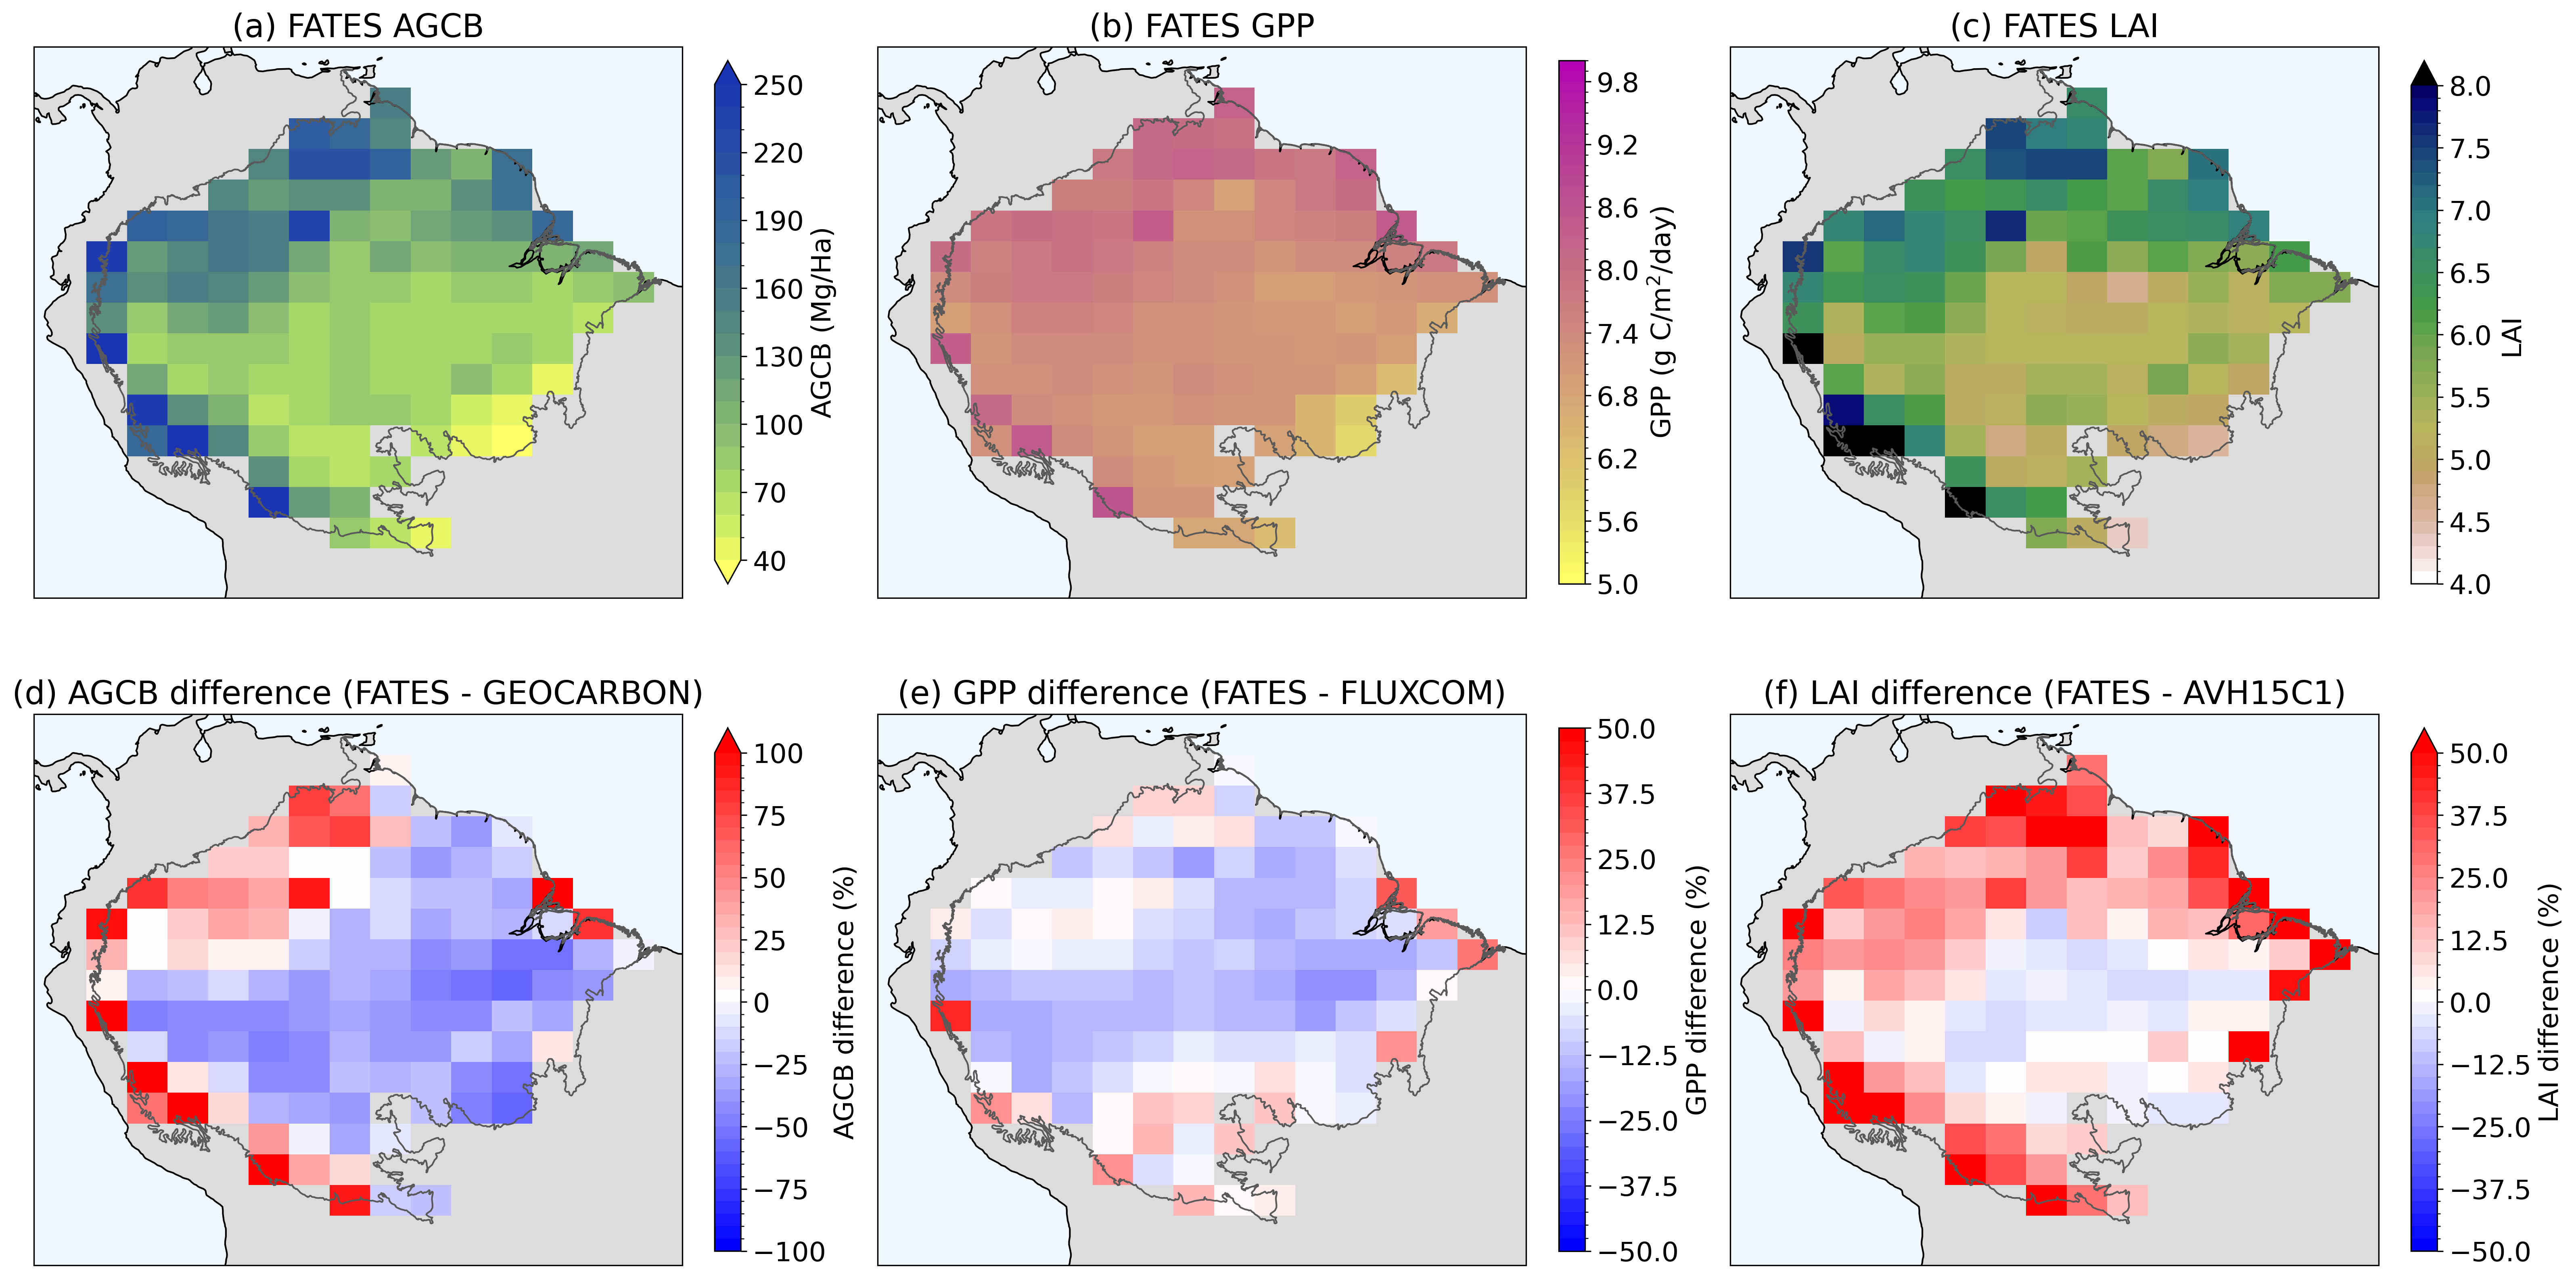

In [18]:
# Make a six-panel figure showing GPP, GPP difference, AGCB, AGCB difference, LAI, LAI difference

# Create figure with 6 subplots (3 rows, 2 columns)
fig, axes = plt.subplots(2, 3, figsize=(21, 11), 
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         constrained_layout=True)

ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

plt.tight_layout(w_pad=1, h_pad=0.0)

# First panel - above ground carbon biomass
fates_agb=10.*fates.FATES_VEGC_ABOVEGROUND.mean(dim="time")
im1 = fates_agb.where(fates_Amazon_mask > 0).plot(x='lon', y='lat', levels=np.linspace(40,250,22), 
                            cmap=cm.imola_r, transform=ccrs.PlateCarree(), ax=ax1,
                            cbar_kwargs=dict(shrink=0.8,location='right',orientation='vertical',label='AGCB (Mg/Ha)'))
ax1.add_feature(cartopy.feature.LAND, facecolor='gainsboro', zorder=0)
ax1.add_feature(cartopy.feature.OCEAN, facecolor='aliceblue', zorder=0)
ax1.set_title('(a) FATES AGCB')
ax1.coastlines()
ax1.add_geometries(Reader(Amazon_shapefile).geometries(), ccrs.PlateCarree(), 
                           edgecolor=(0.35,0.35,0.35,1), facecolor=(0,0,0,0))
ax1.set_xlim([min_lon_plotting-360., max_lon_plotting-360.])
ax1.set_ylim([min_lat_plotting,max_lat_plotting])

# Second panel - GPP
fates_gpp=fates.FATES_GPP.mean(dim='time')*86400.*1000.
im2 = fates_gpp.where(fates_Amazon_mask > 0).plot(x='lon', y='lat', levels=np.linspace(5,10,51),
                            cmap=cm.buda_r, transform=ccrs.PlateCarree(), ax=ax2,
                            cbar_kwargs=dict(shrink=0.8,location='right',orientation='vertical',label='GPP (g C/m$^2$/day)'))
ax2.add_feature(cartopy.feature.LAND, facecolor='gainsboro', zorder=0)
ax2.add_feature(cartopy.feature.OCEAN, facecolor='aliceblue', zorder=0)
ax2.set_title('(b) FATES GPP')
ax2.coastlines()
ax2.add_geometries(Reader(Amazon_shapefile).geometries(), ccrs.PlateCarree(), 
                            edgecolor=(0.35,0.35,0.35,1), facecolor=(0,0,0,0))
ax2.set_xlim([min_lon_plotting-360., max_lon_plotting-360.])
ax2.set_ylim([min_lat_plotting,max_lat_plotting])

# Third panel - LAI
fates_lai=fates.TLAI.mean(dim="time")
im3 = fates_lai.where(fates_Amazon_mask > 0).plot(x='lon', y='lat', levels=np.linspace(4,8,41),
                            cmap=plt.cm.gist_earth_r, transform=ccrs.PlateCarree(), ax=ax3,
                            cbar_kwargs=dict(shrink=0.8,location='right',orientation='vertical',label='LAI'))
ax3.add_feature(cartopy.feature.LAND, facecolor='gainsboro', zorder=0)
ax3.add_feature(cartopy.feature.OCEAN, facecolor='aliceblue', zorder=0)
ax3.set_title('(c) FATES LAI')
ax3.coastlines()
ax3.add_geometries(Reader(Amazon_shapefile).geometries(), ccrs.PlateCarree(), 
                           edgecolor=(0.35,0.35,0.35,1), facecolor=(0,0,0,0))
ax3.set_xlim([min_lon_plotting-360., max_lon_plotting-360.])
ax3.set_ylim([min_lat_plotting,max_lat_plotting])

# Fourth panel - difference from GEOCARBON in above ground carbon biomass
agb_rel_diff = 100*(fates_agb - geocarb_agb_regrid.mean(dim='time'))/geocarb_agb_regrid.mean(dim='time')
im4 = agb_rel_diff.biomass.where(fates_Amazon_mask > 0).plot(x='lon', y='lat',
                            cmap=plt.cm.bwr,levels=np.linspace(-100,100,41),
                            transform=ccrs.PlateCarree(),ax=ax4,
                            cbar_kwargs=dict(shrink=0.8,location='right',orientation='vertical',label='AGCB difference (%)'))                           
ax4.add_feature(cartopy.feature.LAND, facecolor='gainsboro', zorder=0)
ax4.add_feature(cartopy.feature.OCEAN, facecolor='aliceblue', zorder=0)
ax4.set_title('(d) AGCB difference (FATES - GEOCARBON)')
ax4.coastlines()
ax4.add_geometries(Reader(Amazon_shapefile).geometries(), ccrs.PlateCarree(), 
                           edgecolor=(0.35,0.35,0.35,1), facecolor=(0,0,0,0))
ax4.set_xlim([min_lon_plotting-360., max_lon_plotting-360.])
ax4.set_ylim([min_lat_plotting,max_lat_plotting])


# Fifth panel - difference from FLUXCOM in GPP
gpp_rel_diff_fates_fluxcom = 100.*(fates_gpp - fluxcom_regrid)/fluxcom_regrid
im5 = gpp_rel_diff_fates_fluxcom.__xarray_dataarray_variable__.where(fates_Amazon_mask > 0).plot(x='lon', y='lat',
                            cmap=plt.cm.bwr,transform=ccrs.PlateCarree(),levels=np.linspace(-50,50,41), ax=ax5,
                            cbar_kwargs=dict(shrink=0.8,location='right',orientation='vertical',label='GPP difference (%)'))
ax5.add_feature(cartopy.feature.LAND, facecolor='gainsboro', zorder=0)
ax5.add_feature(cartopy.feature.OCEAN, facecolor='aliceblue', zorder=0)
ax5.set_title('(e) GPP difference (FATES - FLUXCOM)')
ax5.coastlines()
ax5.add_geometries(Reader(Amazon_shapefile).geometries(), ccrs.PlateCarree(), 
                            edgecolor=(0.35,0.35,0.35,1), facecolor=(0,0,0,0))
ax5.set_xlim([min_lon_plotting-360., max_lon_plotting-360.])
ax5.set_ylim([min_lat_plotting,max_lat_plotting])


# Sixth panel - difference from AVH15C1 in LAI
lai_rel_diff = 100.*(fates_lai - lai_regrid)/lai_regrid
im6 = lai_rel_diff.__xarray_dataarray_variable__.where(fates_Amazon_mask > 0).plot(x='lon', y='lat',
                            cmap=plt.cm.bwr,transform=ccrs.PlateCarree(),levels=np.linspace(-50,50,41), ax=ax6,
                            cbar_kwargs=dict(shrink=0.8,location='right',orientation='vertical',label='LAI difference (%)'))
ax6.add_feature(cartopy.feature.LAND, facecolor='gainsboro', zorder=0)
ax6.add_feature(cartopy.feature.OCEAN, facecolor='aliceblue', zorder=0)
ax6.set_title('(f) LAI difference (FATES - AVH15C1)')
ax6.coastlines()
ax6.add_geometries(Reader(Amazon_shapefile).geometries(), ccrs.PlateCarree(), 
                           edgecolor=(0.35,0.35,0.35,1), facecolor=(0,0,0,0))
ax6.set_xlim([min_lon_plotting-360., max_lon_plotting-360.])
ax6.set_ylim([min_lat_plotting,max_lat_plotting])


In [15]:
ba_szpf=fa.scpf_to_scls_by_pft(fates.FATES_BASALAREA_SZPF,fates)

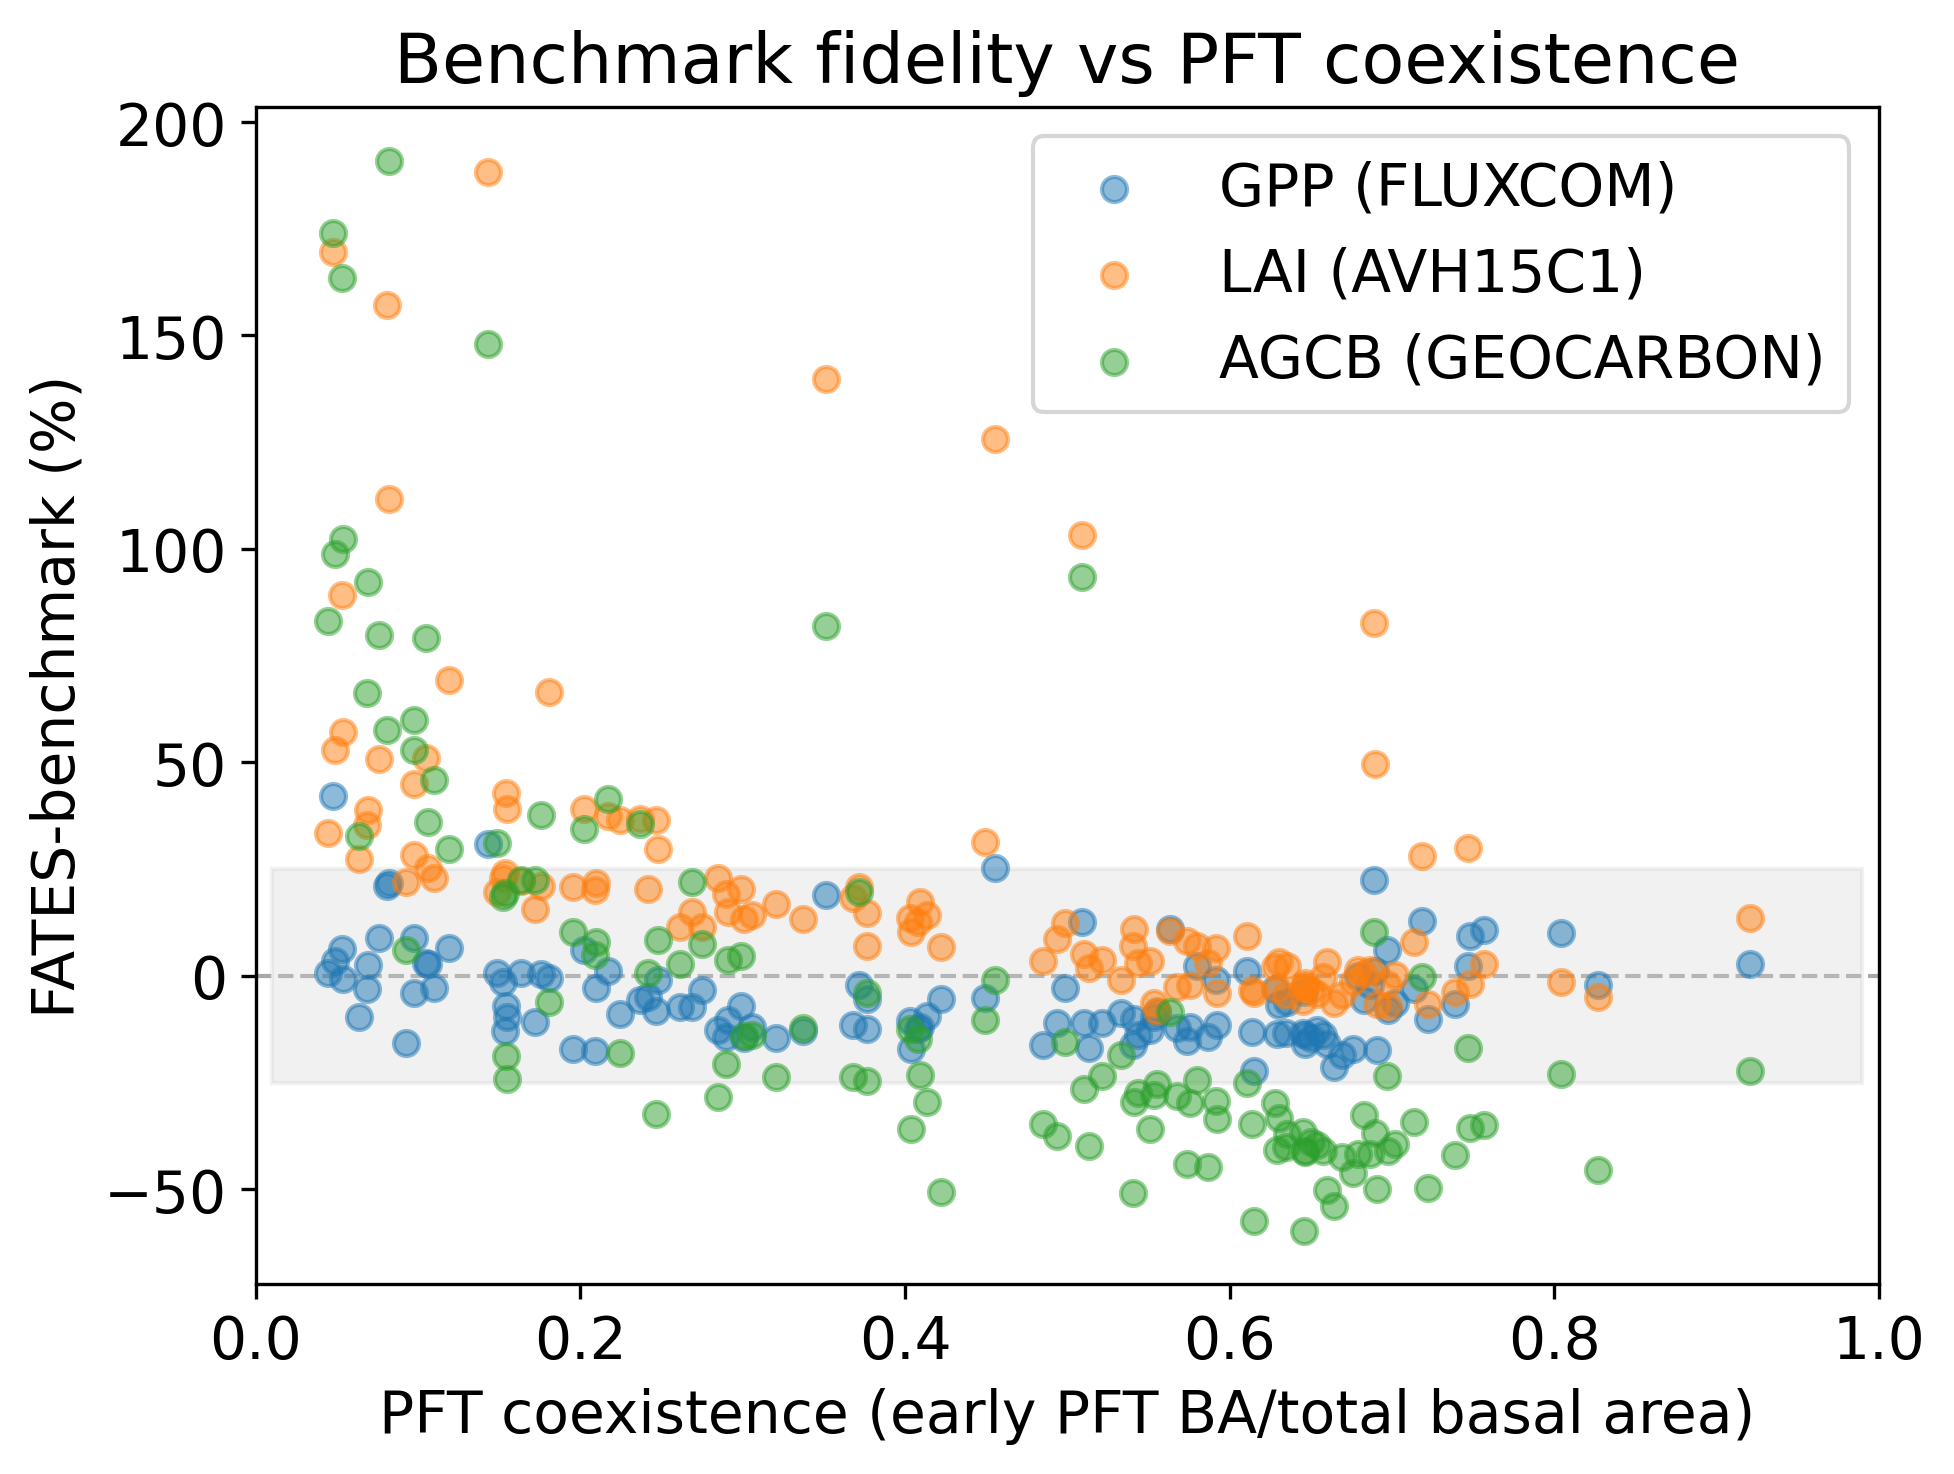

In [23]:
plt.rcParams['font.size'] = 14

pft_ratio=(ba_szpf.sum(dim='fates_levscls').isel(fates_levpft=0).mean(dim="time"))/(ba_szpf.sum(dim='fates_levscls').sum(dim='fates_levpft').mean(dim="time"))

plt.scatter(pft_ratio.where(fates_Amazon_mask > 0).values.flatten(),gpp_rel_diff_fates_fluxcom.__xarray_dataarray_variable__.where(fates_Amazon_mask > 0).values.flatten(),label="GPP (FLUXCOM)",alpha=0.5)
plt.scatter(pft_ratio.where(fates_Amazon_mask > 0).values.flatten(),lai_rel_diff.__xarray_dataarray_variable__.where(fates_Amazon_mask > 0).values.flatten(),label="LAI (AVH15C1)",alpha=0.5)
plt.scatter(pft_ratio.where(fates_Amazon_mask > 0).values.flatten(),agb_rel_diff.biomass.where(fates_Amazon_mask > 0).values.flatten(),label="AGCB (GEOCARBON)",alpha=0.5)
plt.xlabel('PFT coexistence (early PFT BA/total basal area)')
plt.ylabel('FATES-benchmark (%)')
plt.title('Benchmark fidelity vs PFT coexistence')
plt.xlim(0,1)
plt.axhline(y=0, color='darkgrey', linestyle='--', linewidth=1,zorder=0)
#plt.axhline(y=25, color='lightgrey', linestyle='dotted', linewidth=1,zorder=0)
#plt.axhline(y=-25, color='lightgrey', linestyle='dotted', linewidth=1,zorder=0)
plt.fill([0.01, 0.99, 0.99, 0.01], [-25, -25, 25, 25], color='lightgrey', alpha=0.3, zorder=0)
#plt.fill([0.15, 0.5, 0.5, 0.15], [-25, -25, 25, 25], color='grey', alpha=0.3, zorder=0)

plt.legend()
#plt.ylim(-100,100)
plt.show()

In [20]:
# Flatten and clean data (remove NaNs)
x_data = pft_ratio.where(fates_Amazon_mask > 0).values.flatten()
y_gpp = gpp_rel_diff_fates_fluxcom.__xarray_dataarray_variable__.where(fates_Amazon_mask > 0).values.flatten()
y_lai = lai_rel_diff.__xarray_dataarray_variable__.where(fates_Amazon_mask > 0).values.flatten()
y_agb = agb_rel_diff.biomass.where(fates_Amazon_mask > 0).values.flatten()

# For each variable, calculate the statistics
for name, y_data in [("GPP", y_gpp), ("LAI", y_lai), ("AGCB", y_agb)]:
    # Remove NaN pairs
    valid_mask = ~np.isnan(x_data) & ~np.isnan(y_data)
    x_valid = x_data[valid_mask]
    y_valid = y_data[valid_mask]
    
    # Find points within y = [-25, 25]
    within_y_range = (y_valid >= -25) & (y_valid <= 25)
    n_within_y = np.sum(within_y_range)
    n_total = len(y_valid)
    
    # Calculate percentage of all points within y range
    percentage = 100 * n_within_y / n_total
    
    # Get the x-values for points within y range
    x_within_y = x_valid[within_y_range]
    
    # Calculate min and max x-values for those points
    if n_within_y > 0:
        x_min = np.min(x_within_y)
        x_max = np.max(x_within_y)
        q95, q05 = np.percentile(x_within_y, [95, 5])

        print(f"{name}:")
        print(f"  {percentage:.1f}% of points within y=±25 ({n_within_y}/{n_total})")
        print(f"  x-range for those points: [{x_min:.3f}, {x_max:.3f}]")
        print(f" q05={q05:0.3f}, q95={q95:0.3f}")
        print()
    else:
        print(f"{name}: No points within y range")
        print()


GPP:
  97.5% of points within y=±25 (119/122)
  x-range for those points: [0.044, 0.921]
 q05=0.069, q95=0.740

LAI:
  72.1% of points within y=±25 (88/122)
  x-range for those points: [0.092, 0.921]
 q05=0.157, q95=0.745

AGCB:
  36.1% of points within y=±25 (44/122)
  x-range for those points: [0.092, 0.921]
 q05=0.153, q95=0.743

